In [1]:
s # Cell 1: Imports and utility functions
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles, make_blobs
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from confidence.direct.logit_based import EnergyConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence
from confidence.model.single_pass import SinglePassConfidence
from confidence.utils import ModelInputWrapper


# Helper to plot 2D confidence
def plot_confidence_grid(model, conf, X, y, title, ax, device="cpu"):
    xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    with torch.no_grad():
        grid_tensor = torch.tensor(grid, dtype=torch.float32).to(device)
        conf_scores = conf(model(grid_tensor)).cpu().numpy()
    conf_scores = conf_scores.reshape(xx.shape)
    ax.contourf(xx, yy, conf_scores, levels=50, cmap="viridis", alpha=0.7)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=30)
    ax.set_title(title)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)

In [2]:
# Cell 1: Imports and utility functions
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles, make_blobs
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from confidence.direct.logit_based import EnergyConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence
from confidence.model.single_pass import SinglePassConfidence

# Helper to plot 2D confidence
def plot_confidence_grid(model, conf, X, y, title, ax, device="cpu"):
    xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    with torch.no_grad():
        grid_tensor = torch.tensor(grid, dtype=torch.float32).to(device)
        conf_scores = conf(grid_tensor).cpu().numpy()
    conf_scores = conf_scores.reshape(xx.shape)
    ax.contourf(xx, yy, conf_scores, levels=500, cmap="viridis", alpha=1.0)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=30)
    ax.set_title(title)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)

In [3]:
# Cell 2: Dataset generators
def make_u_with_ball(n_samples=500, noise=0.05):
    # U shape
    theta = np.linspace(np.pi, 2 * np.pi, n_samples // 2)
    x_u = np.c_[np.cos(theta), np.sin(theta)]
    # Ball in the middle
    r = 0.3
    phi = np.random.uniform(0, 2 * np.pi, n_samples // 2)
    x_ball = np.c_[r * np.cos(phi), r * np.sin(phi)]
    X = np.vstack([x_u, x_ball])
    y = np.array([0] * (n_samples // 2) + [1] * (n_samples // 2))
    X += np.random.normal(scale=noise, size=X.shape)
    return X, y

def make_xor_blobs(n_samples=500, noise=0.1):
    X, y = make_blobs(n_samples=n_samples, centers=[[-1, -1], [1, 1], [-1, 1], [1, -1]], cluster_std=noise)
    y = np.array([0 if (a[0] * a[1] > 0) else 1 for a in X])
    return X, y

def make_gaussian_clusters(n_samples=500, noise=0.1):
    X, y = make_blobs(n_samples=n_samples, centers=[[-1, 0], [1, 0]], cluster_std=noise)
    return X, y

# List of dataset generators
dataset_generators = [
    lambda: make_moons(n_samples=500, noise=0.1),
    lambda: make_u_with_ball(n_samples=500, noise=0.05),
    lambda: make_circles(n_samples=500, noise=0.05, factor=0.5),
    lambda: make_xor_blobs(n_samples=500, noise=0.1),
    lambda: make_gaussian_clusters(n_samples=500, noise=0.1),
]
dataset_names = [
    "Two Moons",
    "U with Ball",
    "Concentric Circles",
    "XOR Blobs",
    "Gaussian Clusters"
]

In [4]:
class SimpleMLP(nn.Module):
    def __init__(self, in_dim=2, hidden=32, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, out_dim)
        )
    def forward(self, x):
        return self.net(x)

In [5]:

def make_and_train_model(dataset=make_moons, n_samples=500, noise=0.1):
    # Device configuration
    device = "cuda" if torch.cuda.is_available() else "cpu"

    data = dataset()
    X, y = data

    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.long)
    ds = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(ds, batch_size=64, shuffle=True)
        # Model
    model = SimpleMLP().net.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
    criterion = nn.CrossEntropyLoss()
    # Train
    for epoch in range(100):
            for xb, yb in loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                out = model(xb)
                loss = criterion(out, yb)
                loss.backward()
                optimizer.step()
        # Get logits for all data
    with torch.no_grad():
        logits = model(X_tensor.to(device)).cpu()
        # Fit confidence modules
    return model, logits, X_tensor, y_tensor


In [6]:
import torch
from confidence.direct.logit_based import EnergyConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence
from confidence.model.single_pass import SinglePassConfidence
from confidence.unsupervised.classic.VIM import ViMTorchConfidence
from confidence.utils import ModelInputWrapper
def extract_embeddings(model, loader):
    embeddings = []
    classes = []
    for data, target in loader:
        with torch.no_grad():
            emb = model[:-1](data.cuda()).cpu()  # adjust slicing as needed
        embeddings.append(emb)
        classes.append(target)
    embeddings = torch.cat(embeddings)
    classes = torch.cat(classes)
    embeddings=embeddings.cuda()
    classes=classes.cuda()

    conf_energy = EnergyConfidence().cuda()
    conf_knn = KNNConfidence(k=3,metric="cosine").cuda()
    conf_knn.fit(embeddings, classes)
    conf_knn2 = KNNConfidence(k=3,metric="euclidean").cuda()
    conf_knn2.fit(embeddings, classes)
    conf_knn3 = KNNConfidence(k=3,metric="mahalanobis").cuda()
    conf_knn3.fit(embeddings, classes)
    conf_vim = ViMTorchConfidence(model=model, n_dim=4).cuda()
    conf_vim.fit(embeddings, classes)

    conf_energy = SinglePassConfidence(model,conf_energy)
    conf_knn = SinglePassConfidence(model[:-1],conf_knn,index=0)
    conf_vim = SinglePassConfidence(model[:-1],conf_vim,index=0)
    conf_knn2 = SinglePassConfidence(model[:-1],conf_knn2,index=0)
    conf_knn3 = SinglePassConfidence(model[:-1],conf_knn3,index=0)
    return lambda x: conf_energy(x)[0], \
           lambda x: conf_knn(x)[0], \
           lambda x: conf_vim(x)[0], \
           lambda x: conf_knn2(x)[0], \
           lambda x: conf_knn3(x)[0]







In [8]:
# List of dataset generators
n_samples = 100
noise = 0.1

dataset_generators = [
    lambda: make_moons(n_samples=n_samples, noise=noise),
    lambda: make_u_with_ball(n_samples=n_samples, noise=noise),
    lambda: make_circles(n_samples=n_samples, noise=noise, factor=0.1),
    lambda: make_xor_blobs(n_samples=n_samples, noise=noise),
    lambda: make_gaussian_clusters(n_samples=n_samples, noise=noise),
]
dataset_names = [
    "Two Moons",
    "U with Ball",
    "Concentric Circles",
    "XOR Blobs",
    "Gaussian Clusters"
]

Generating dataset: Two Moons
Generating dataset: U with Ball
Generating dataset: Concentric Circles
Generating dataset: XOR Blobs
Generating dataset: Gaussian Clusters


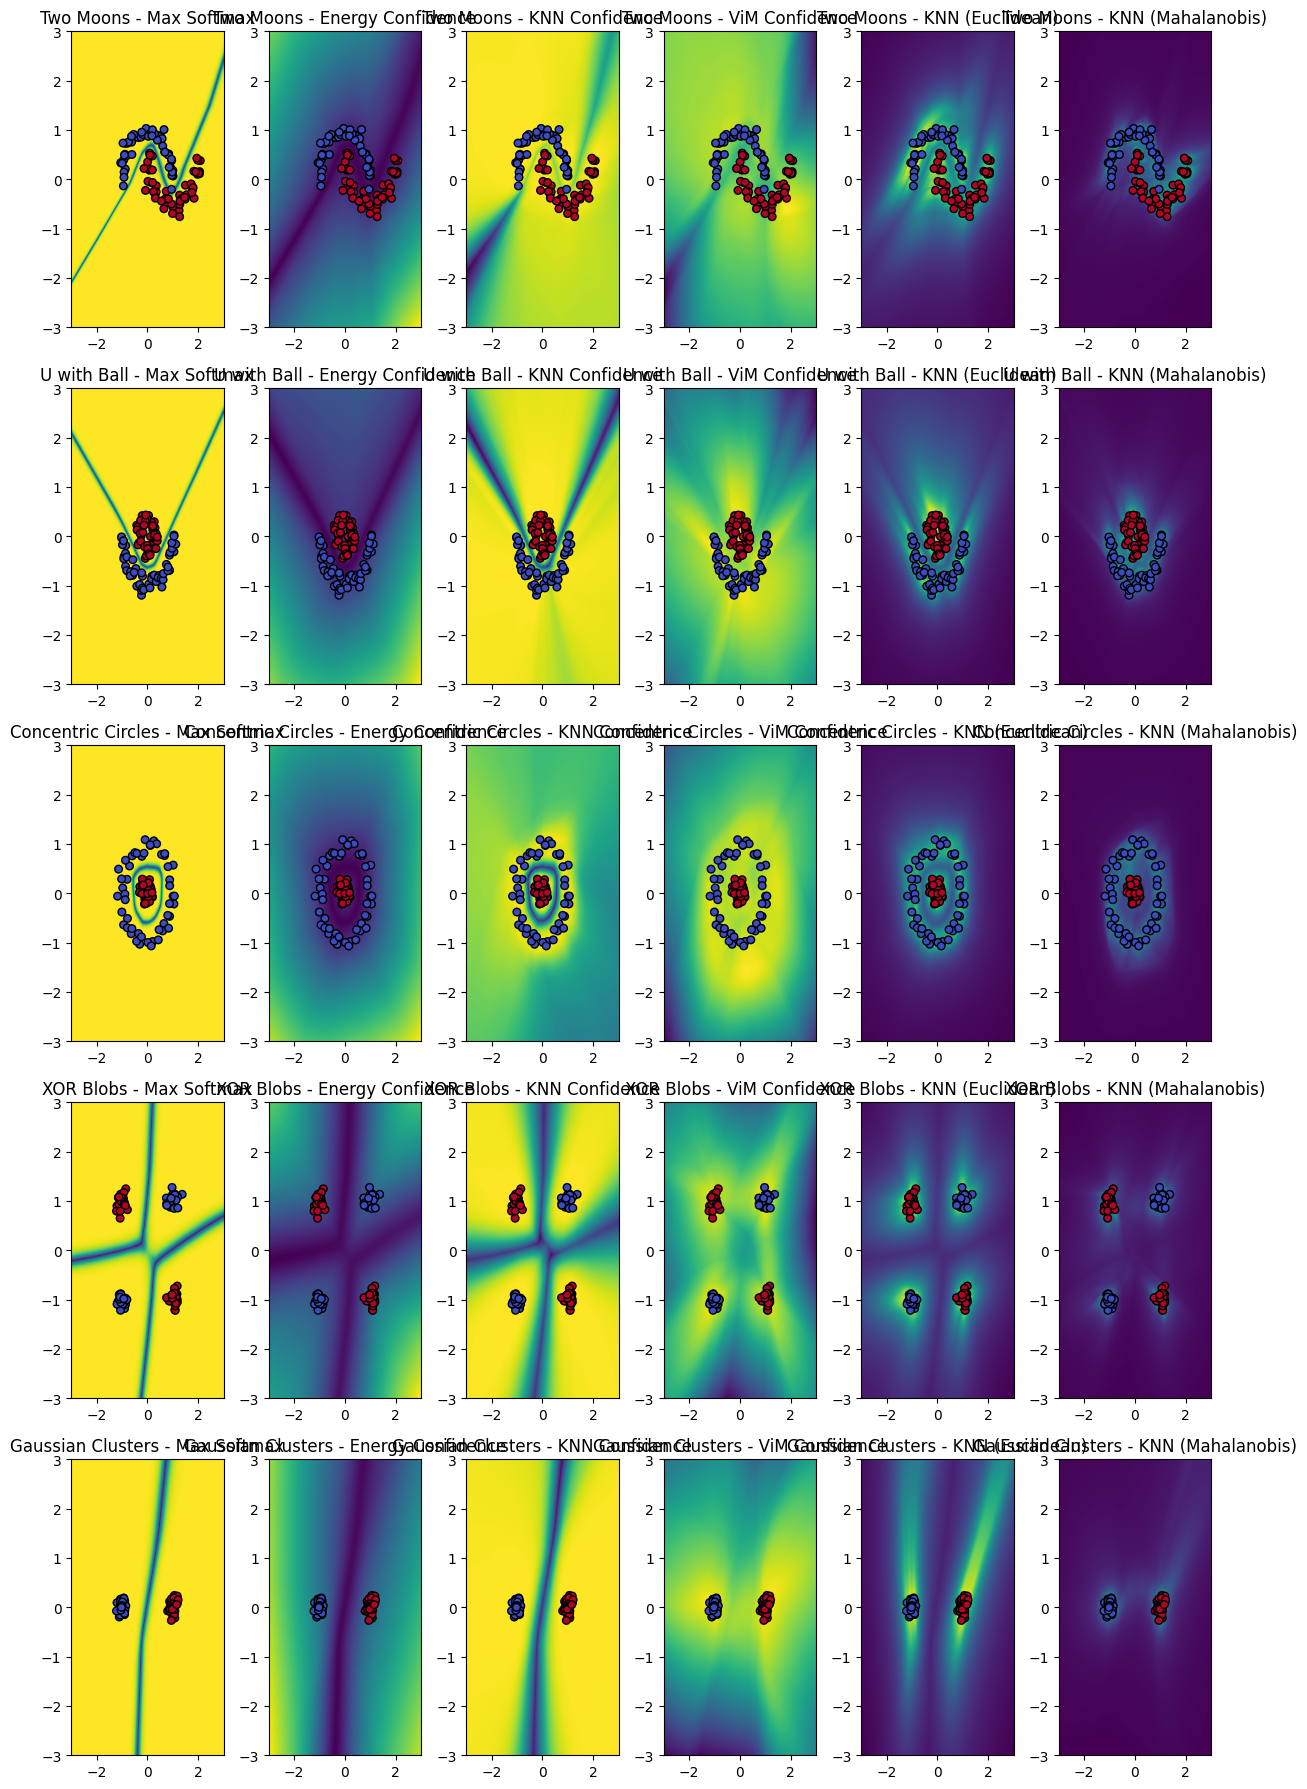

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
fig, axs = plt.subplots(len(dataset_generators), 6, figsize=(12, 18))
for i, (gen, name) in enumerate(zip(dataset_generators, dataset_names)):
    print("Generating dataset:", name)
    model, logits, X, y = make_and_train_model(gen)
    conf_energy,conf_knn, conf_vim, conf_knn2, conf_knn3 = extract_embeddings(model, DataLoader(TensorDataset(X, y), batch_size=64))


    # Plot decision boundary
    plot_confidence_grid(model, lambda x: torch.softmax(model(x), -1).max(-1)[0], X, y, f"{name} - Max Softmax", axs[i, 0], device=device)

    plot_confidence_grid(model, conf_energy, X, y, f"{name} - Energy Confidence", axs[i, 1], device=device)

    plot_confidence_grid(model, conf_knn, X, y, f"{name} - KNN Confidence", axs[i, 2], device=device)

    plot_confidence_grid(model, conf_vim, X, y, f"{name} - ViM Confidence", axs[i, 3], device=device)
    plot_confidence_grid(model, conf_knn2, X, y, f"{name} - KNN (Euclidean)", axs[i, 4], device=device)
    plot_confidence_grid(model, conf_knn3, X, y, f"{name} - KNN (Mahalanobis)", axs[i, 5], device=device)
plt.tight_layout()
plt.show()